# DSV A/S — Fundamental Analysis
**Gabriel Baker | github.com/gabrielbaker**

DSV is the world's third-largest freight forwarder by revenue, operating across Air & Sea, Road, and Contract Logistics.  
This notebook works through a full fundamental analysis using DSV's reported financial data (2010–2025), covering growth, profitability, cash flow quality, capital structure, returns, and divisional dynamics.

> *Data source: DSV A/S financial detail files. All figures in DKKm unless stated.*


## 1. Data Preparation

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Styling ────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
COLORS = {"primary": "#1f4e79", "secondary": "#2e75b6", "accent": "#70ad47",
          "warning": "#ffc000", "red": "#c00000", "grey": "#808080"}
FIG_KW = dict(figsize=(14, 5), dpi=130)

# ── Annual P&L (DKKm) ─────────────────────────────────────────────────────────
years = list(range(2010, 2026))

pl = pd.DataFrame({
    "year": years,
    "revenue":        [42562, 43710, 44912, 45710, 48582, 50869, 67747, 74901, 79053, 94701,
                       115932, 182306, 235665, 150785, 167106, 247331],
    "gross_profit":   [9320, 9819, 10054, 10005, 10297, 11201, 15838, 16605, 17489, 23754,
                       28534, 37615, 52149, 43818, 42974, 66859],
    "ebitda":         [2721, 2975, 3074, 3052, 3145, 3575, 4250, 5664, 6212, 10292,
                       13559, 20417, 30275, 22997, 21831, 28244],
    "ebit":           [2202, 2426, 2540, 2552, 2624, 3050, 3475, 4878, 5450, 6654,
                       9520, 16223, 25204, 17723, 16096, 19611],
    "pbt":            [1660, 1995, 2019, 2125, 2014, 2689, 2289, 3797, 5201, 4996,
                       5627, 14904, 23221, 16490, 13423, 12147],
    "net_profit":     [1194, 1449, 1430, 1571, 1491, 2058, 1678, 3012, 3988, 3706,
                       4258, 11254, 17671, 12407, 10175, 8463],
    "employees":      [21300, 21678, 21932, 22021, 22874, 22783, 44779, 45636, 47394, 61216,
                       56621, 77958, 76283, 73577, 73338, 151751],
}).set_index("year")

# Derived margins
pl["gross_margin"]   = pl["gross_profit"] / pl["revenue"] * 100
pl["ebitda_margin"]  = pl["ebitda"]       / pl["revenue"] * 100
pl["ebit_margin"]    = pl["ebit"]         / pl["revenue"] * 100
pl["net_margin"]     = pl["net_profit"]   / pl["revenue"] * 100

# ── Balance Sheet (DKKm) ──────────────────────────────────────────────────────
bs = pd.DataFrame({
    "year": years,
    "total_assets":     [23085, 22734, 22794, 23100, 23680, 27725, 40367, 38388, 38812, 97557,
                         96250, 161395, 159045, 147110, 236545, 290373],
    "intangibles":      [8772, 8683, 8723, 8982, 8928, 8996, 17247, 16573, 16742, 51988,
                         48665, 76661, 77674, 77106, 77877, 150954],
    "ppe":              [4782, 4503, 4261, 3883, 3927, 3568, 3334, 2431, 2297, 3022,
                         3014, 6262, 6284, 6214, 6779, 24421],
    "rou_assets":       [0, 0, 0, 0, 0, 0, 0, 0, 193, 11671, 11111, 13709, 14694, 15655, 18713, 27772],
    "trade_receivables":[7155, 7112, 7238, 7469, 7854, 7799, 12338, 12557, 13252, 18252,
                         19038, 36369, 32387, 22296, 27222, 45130],
    "cash":             [363, 367, 552, 707, 432, 4908, 1714, 1348, 1158, 2043,
                         4060, 8299, 10160, 6452, 83576, 13179],
    "total_equity":     [6585, 5309, 5385, 6248, 6081, 11841, 13378, 14809, 14532, 49319,
                         47297, 74278, 71741, 68966, 114503, 117690],
    "lt_borrowings":    [5642, 6091, 6190, 6066, 5702, 4309, 8725, 6491, 6461, 6464,
                         7696, 16993, 21398, 20004, 60852, 56950],
    "st_borrowings":    [593, 861, 923, 590, 589, 313, 1358, 495, 485, 1520,
                         1185, 4472, 814, 2139, 292, 10055],
    "lt_lease":         [0, 0, 0, 0, 0, 0, 0, 0, 132, 9227, 9428, 11848, 13190, 14139, 17324, 24084],
    "st_lease":         [0, 0, 0, 0, 0, 0, 0, 0, 60, 3385, 2850, 3440, 3577, 3808, 4349, 6846],
    "nwc":              [70, 1, 307, 561, 305, 22, 1809, 1410, 1767, 3125,
                         2701, 8031, 5116, 4742, 9317, 1242],
}).set_index("year")

bs["gross_debt"]     = bs["lt_borrowings"] + bs["st_borrowings"]
bs["net_debt_excl_lease"] = bs["gross_debt"] - bs["cash"]
bs["net_debt_incl_lease"] = bs["gross_debt"] + bs["lt_lease"] + bs["st_lease"] - bs["cash"]
bs["equity_ratio"]   = bs["total_equity"] / bs["total_assets"] * 100
bs["tangible_equity"] = bs["total_equity"] - bs["intangibles"]

# ── Cash Flow (DKKm) ──────────────────────────────────────────────────────────
cf = pd.DataFrame({
    "year": years,
    "cfo":          [1663, 1863, 1651, 1775, 1919, 3160, 1273, 4664, 4301, 6879,
                     10276, 12202, 26846, 16458, 11651, 21481],
    "capex":        [445, 644, 578, 403, 603, 581, 795, 1013, 1210, 1292,
                     1341, 1483, 1794, 2375, 2429, 2588],
    "adj_fcf":      [1566, 1894, 1509, 1754, 1472, 2837, 1838, 4835, 3916, 3678,
                     8746, 8659, 22810, 11471, 5550, 16335],
    "dividends":    [52, 105, 190, 235, 270, 283, 327, 342, 380, 423,
                     588, 920, 1320, 1424, 1533, 1683],
    "buybacks":     [397, 2505, 1302, 700, 1183, 1419, 0, 1559, 4161, 4888,
                     5031, 17841, 20313, 13997, 3347, 0],
}).set_index("year")

cf["fcf_excl_acq"] = cf["cfo"] - cf["capex"]
cf["cfo_to_ebitda"] = cf["cfo"] / pl["ebitda"] * 100
cf["capex_intensity"] = cf["capex"] / pl["revenue"] * 100
cf["shareholder_return"] = cf["dividends"] + cf["buybacks"]

# ── Divisional P&L (DKKm) ─────────────────────────────────────────────────────
div = pd.DataFrame({
    "year": years,
    "as_rev":    [19404,18926,19855,20195,22001,21685,32100,35204,36972,51151,
                  73689,131901,174431,92972,104496,137320],
    "as_ebit":   [1213,1355,1412,1392,1542,1923,2143,3225,3693,4506,
                  7026,12768,20658,13363,11888,13013],
    "road_rev":  [21103,22641,22654,23117,24169,24718,28323,30627,31243,31621,
                  30395,35416,41507,38155,40507,77977],
    "road_ebit": [771,834,933,942,837,918,1049,1201,1147,1251,
                  1390,1857,2040,2009,1864,2735],
    "cl_rev":    [4861,5009,5181,5470,5729,5960,9683,11362,13229,14390,
                  14608,18734,24409,23140,25624,43463],
    "cl_ebit":   [268,278,250,256,274,242,384,494,709,1013,
                  1161,1775,2701,2355,2328,3806],
    "air_vol":   [248797,262362,259057,259365,287662,311193,574644,635655,689045,1071266,
                  1272405,1510833,1557972,1305827,1398398,2013127],
}).set_index("year")

div["as_margin"]   = div["as_ebit"]   / div["as_rev"]   * 100
div["road_margin"] = div["road_ebit"] / div["road_rev"]  * 100
div["cl_margin"]   = div["cl_ebit"]   / div["cl_rev"]    * 100
div["total_div_rev"] = div["as_rev"] + div["road_rev"] + div["cl_rev"]

print("Data loaded successfully.")
print(f"P&L: {pl.shape} | BS: {bs.shape} | CF: {cf.shape} | Div: {div.shape}")
pl.tail(3)[["revenue","ebit","ebit_margin","net_profit"]]




Data loaded successfully.
P&L: (16, 11) | BS: (16, 17) | CF: (16, 9) | Div: (16, 11)


,revenue,ebit,ebit_margin,net_profit
year,,,,
2023,150785,17723,11.753822,12407
2024,167106,16096,9.632209,10175
2025,247331,19611,7.929051,8463


## 2. Revenue & Growth

DSV's revenue trajectory reflects both organic growth and three transformative acquisitions:
- **2016**: UTi Worldwide (logistics, +~DKK 17bn)
- **2019**: Panalpina (air & sea, +~DKK 45bn)
- **2021**: Agility GIL (emerging markets logistics)
- **2025**: DB Schenker (completed 2025, largest deal in freight forwarding history)


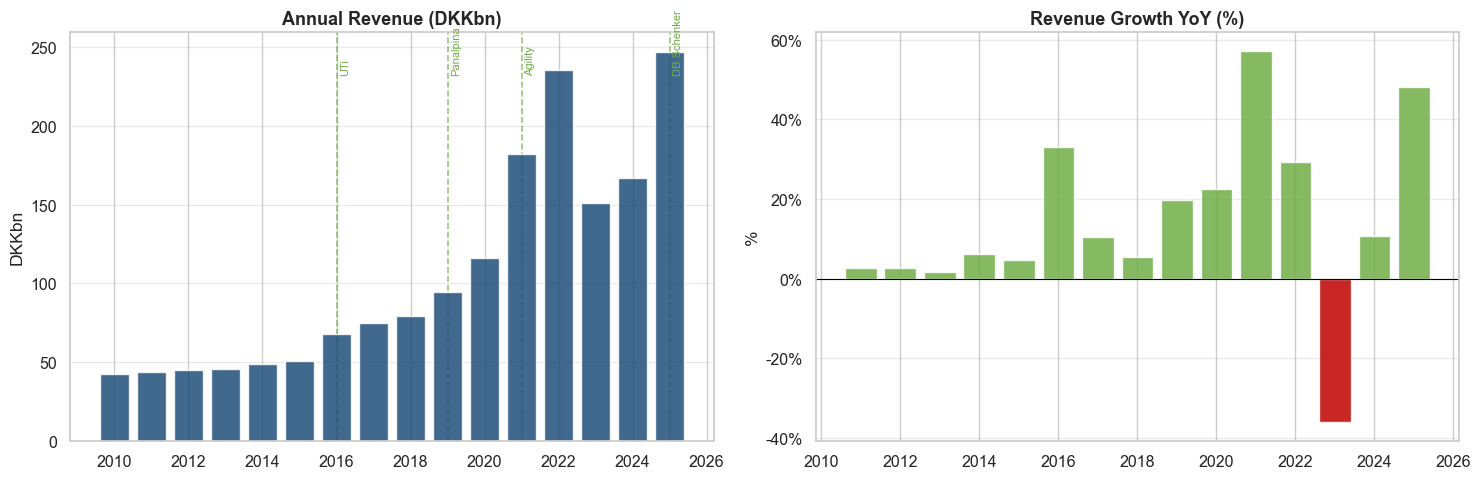

Revenue CAGRs:
  2010-2025 (full): 12.4%
  2010-2019 (pre-DB Schenker): 9.3%
  2019-2022 (super-cycle): 35.5%
  2022-2025 (normalisation+DB Schenker): 1.6%


In [5]:
# ── Revenue growth & YoY change ───────────────────────────────────────────────
pl["rev_growth"] = pl["revenue"].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Absolute revenue with acquisition annotations
ax = axes[0]
bars = ax.bar(pl.index, pl["revenue"] / 1000, color=COLORS["primary"], alpha=0.85, zorder=2)
ax.set_title("Annual Revenue (DKKbn)", fontsize=13, fontweight="bold")
ax.set_ylabel("DKKbn")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}"))

# Acquisition labels
acquisitions = {2016: "UTi", 2019: "Panalpina", 2021: "Agility", 2025: "DB Schenker"}
for yr, name in acquisitions.items():
    ax.axvline(yr, color=COLORS["accent"], linestyle="--", linewidth=1.2, alpha=0.7, zorder=1)
    ax.text(yr + 0.1, ax.get_ylim()[1] * 0.9, name, fontsize=8, color=COLORS["accent"], rotation=90)

ax.grid(axis="y", alpha=0.4)

# YoY growth
ax = axes[1]
colors_bar = [COLORS["accent"] if g >= 0 else COLORS["red"] for g in pl["rev_growth"].fillna(0)]
ax.bar(pl.index[1:], pl["rev_growth"].dropna(), color=colors_bar[1:], alpha=0.85, zorder=2)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Revenue Growth YoY (%)", fontsize=13, fontweight="bold")
ax.set_ylabel("%")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("fig_revenue.png", bbox_inches="tight")
plt.show()

# CAGRs
def cagr(series, start_yr, end_yr):
    n = end_yr - start_yr
    return ((series[end_yr] / series[start_yr]) ** (1/n) - 1) * 100

print("Revenue CAGRs:")
for period, (s, e) in [("2010-2025 (full)", (2010, 2025)),
                        ("2010-2019 (pre-DB Schenker)", (2010, 2019)),
                        ("2019-2022 (super-cycle)", (2019, 2022)),
                        ("2022-2025 (normalisation+DB Schenker)", (2022, 2025))]:
    print(f"  {period}: {cagr(pl['revenue'], s, e):.1f}%")


## 3. Profitability & Margin Analysis

The gross margin — DSV's 'conversion ratio' (gross profit / revenue) — is the cleanest measure of pricing power and mix, since DSV is an asset-light forwarder: direct costs are largely pass-through freight costs.

EBIT margin expansion reflects scale, operational leverage, and the integration of acquisitions.


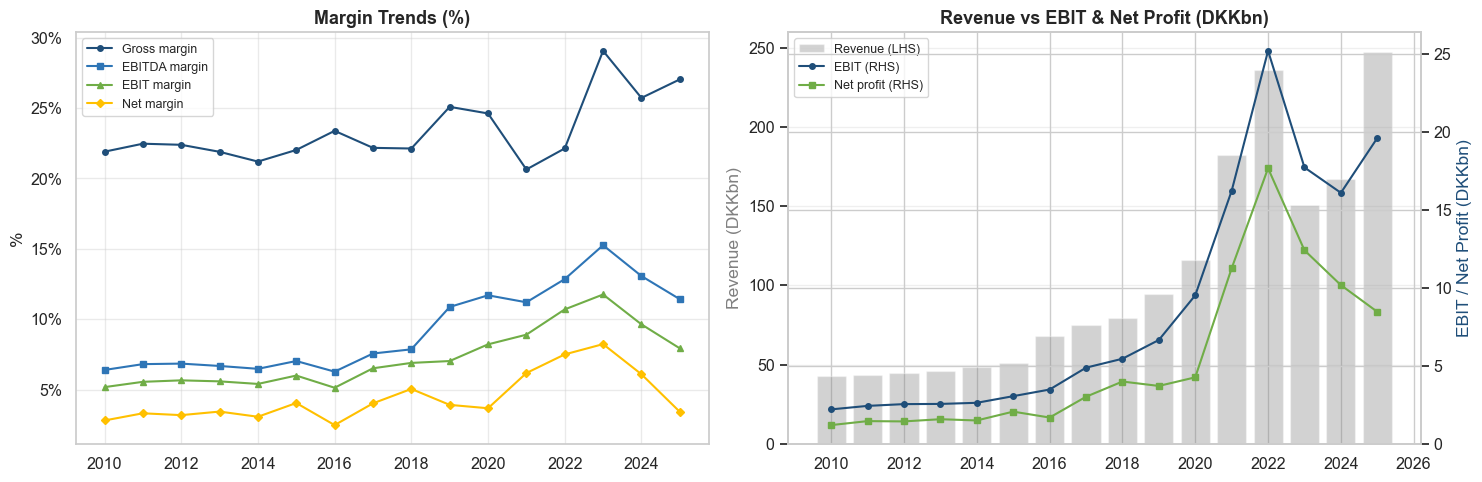


Margin summary (recent years):
      gross_margin  ebitda_margin  ebit_margin  net_margin
year                                                      
2020          24.6           11.7          8.2         3.7
2021          20.6           11.2          8.9         6.2
2022          22.1           12.8         10.7         7.5
2023          29.1           15.3         11.8         8.2
2024          25.7           13.1          9.6         6.1
2025          27.0           11.4          7.9         3.4


In [6]:
# ── Margin trends ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(pl.index, pl["gross_margin"],  marker="o", ms=4, label="Gross margin",  color=COLORS["primary"])
ax.plot(pl.index, pl["ebitda_margin"], marker="s", ms=4, label="EBITDA margin", color=COLORS["secondary"])
ax.plot(pl.index, pl["ebit_margin"],   marker="^", ms=4, label="EBIT margin",   color=COLORS["accent"])
ax.plot(pl.index, pl["net_margin"],    marker="D", ms=4, label="Net margin",    color=COLORS["warning"])
ax.set_title("Margin Trends (%)", fontsize=13, fontweight="bold")
ax.set_ylabel("%")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.legend(fontsize=9)
ax.grid(alpha=0.4)

# Absolute EBIT vs revenue (dual axis)
ax = axes[1]
ax2 = ax.twinx()
ax.bar(pl.index, pl["revenue"] / 1000, color=COLORS["grey"], alpha=0.35, label="Revenue (LHS)")
ax2.plot(pl.index, pl["ebit"] / 1000,   color=COLORS["primary"],   marker="o", ms=4, label="EBIT (RHS)")
ax2.plot(pl.index, pl["net_profit"] / 1000, color=COLORS["accent"], marker="s", ms=4, label="Net profit (RHS)")
ax.set_title("Revenue vs EBIT & Net Profit (DKKbn)", fontsize=13, fontweight="bold")
ax.set_ylabel("Revenue (DKKbn)", color=COLORS["grey"])
ax2.set_ylabel("EBIT / Net Profit (DKKbn)", color=COLORS["primary"])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}"))
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper left")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("fig_margins.png", bbox_inches="tight")
plt.show()

# Print key margin table for recent years
print("\nMargin summary (recent years):")
print(pl[["gross_margin","ebitda_margin","ebit_margin","net_margin"]].tail(6).round(1).to_string())


## 4. Cash Flow Quality

For an asset-light forwarder, operating cash flow conversion (CFO / EBITDA) is the primary quality metric. High conversion indicates low working capital drag and limited non-cash EBITDA inflation. 

Adjusted FCF (DSV's own metric) strips out acquisition costs, special items, and lease repayments to show underlying cash generation.


In [ ]:
# ── Cash flow quality ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# CFO conversion
ax = axes[0]
ax.bar(cf.index, cf["cfo_to_ebitda"], color=COLORS["secondary"], alpha=0.85)
ax.axhline(100, color=COLORS["red"], linestyle="--", linewidth=1.2, label="100% conversion")
ax.set_title("CFO / EBITDA — Cash Conversion (%)", fontsize=13, fontweight="bold")
ax.set_ylabel("%")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.4)

# FCF waterfall (adj FCF, dividends, buybacks)
ax = axes[1]
ax.fill_between(cf.index, cf["adj_fcf"] / 1000, alpha=0.5, color=COLORS["primary"], label="Adj. FCF")
ax.plot(cf.index, cf["adj_fcf"] / 1000,       color=COLORS["primary"], marker="o", ms=4)
ax.plot(cf.index, cf["shareholder_return"] / 1000, color=COLORS["accent"], marker="s", ms=4, 
        linestyle="--", label="Dividends + Buybacks")
ax.set_title("Adjusted FCF vs Shareholder Returns (DKKbn)", fontsize=13, fontweight="bold")
ax.set_ylabel("DKKbn")
ax.legend(fontsize=9)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig("fig_cashflow.png", bbox_inches="tight")
plt.show()

# Capex intensity
print("Capex intensity (capex / revenue):")
print(cf[["capex_intensity"]].tail(8).round(2).to_string())


## 5. Capital Structure & Leverage

DSV has historically run with moderate leverage, using debt capacity to fund acquisitions and then deleveraging through strong cash generation. The 2025 balance sheet reflects the DB Schenker acquisition debt load, with net debt/EBITDA significantly above historical norms.

Note: From 2019 onwards, IFRS 16 lease liabilities appear on the balance sheet. Net debt excluding leases is the more comparable series for credit analysis.


In [ ]:
# ── Leverage & capital structure ──────────────────────────────────────────────
bs_merged = bs.join(pl[["ebitda"]])

bs_merged["nd_ebitda_excl"]  = bs_merged["net_debt_excl_lease"] / bs_merged["ebitda"]
bs_merged["nd_ebitda_incl"]  = bs_merged["net_debt_incl_lease"] / bs_merged["ebitda"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Net debt / EBITDA
ax = axes[0]
ax.bar(bs_merged.index, bs_merged["nd_ebitda_excl"], color=COLORS["primary"], alpha=0.8, label="Excl. leases")
ax.plot(bs_merged.index, bs_merged["nd_ebitda_incl"], color=COLORS["red"], marker="o", ms=4, 
        linewidth=1.8, label="Incl. leases (post-IFRS 16)")
ax.axhline(2.5, color=COLORS["warning"], linestyle="--", linewidth=1.2, label="2.5x reference")
ax.set_title("Net Debt / EBITDA", fontsize=13, fontweight="bold")
ax.set_ylabel("x")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.4)

# Equity ratio and capital stack
ax = axes[1]
equity_pct   = bs["total_equity"] / bs["total_assets"] * 100
gross_debt_pct = bs["gross_debt"] / bs["total_assets"] * 100
lease_pct    = (bs["lt_lease"] + bs["st_lease"]) / bs["total_assets"] * 100

ax.stackplot(bs.index,
             equity_pct,
             gross_debt_pct,
             lease_pct,
             labels=["Equity", "Financial debt", "Lease liabilities"],
             colors=[COLORS["accent"], COLORS["primary"], COLORS["secondary"]],
             alpha=0.8)
ax.set_title("Capital Stack (% of Total Assets)", fontsize=13, fontweight="bold")
ax.set_ylabel("%")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.legend(fontsize=9, loc="lower left")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("fig_leverage.png", bbox_inches="tight")
plt.show()

print("\nLeverage snapshot:")
print(bs_merged[["gross_debt","net_debt_excl_lease","ebitda","nd_ebitda_excl"]].tail(6).round(0).to_string())


## 6. Return Metrics — ROIC & ROE

ROIC (Return on Invested Capital) is the most informative metric for capital allocation quality. For DSV, invested capital is dominated by goodwill from acquisitions, making ROIC sensitive to deal pricing.

**ROIC = NOPAT / Invested Capital**  
where NOPAT = EBIT × (1 − effective tax rate) and Invested Capital = Equity + Net Financial Debt (excl. leases)


In [ ]:
# ── ROIC & ROE ────────────────────────────────────────────────────────────────
combined = pl.join(bs[["total_equity","net_debt_excl_lease","intangibles"]]).join(cf[["adj_fcf"]])

combined["eff_tax"] = (pl["pbt"] - pl["net_profit"]) / pl["pbt"]
combined["nopat"]   = combined["ebit"] * (1 - combined["eff_tax"])
combined["inv_cap"] = combined["total_equity"] + combined["net_debt_excl_lease"]
combined["roic"]    = combined["nopat"] / combined["inv_cap"].shift(1) * 100  # avg IC (prior year)
combined["roe"]     = combined["net_profit"] / combined["total_equity"].shift(1) * 100

# Tangible ROIC (strips goodwill from IC)
combined["tangible_ic"] = combined["inv_cap"] - combined["intangibles"]
combined["tangible_roic"] = combined["nopat"] / combined["tangible_ic"].shift(1) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(combined.index[1:], combined["roic"].dropna(),          marker="o", ms=4, label="ROIC (with goodwill)",    color=COLORS["primary"])
ax.plot(combined.index[1:], combined["tangible_roic"].dropna(), marker="s", ms=4, label="Tangible ROIC",           color=COLORS["accent"])
ax.plot(combined.index[1:], combined["roe"].dropna(),           marker="^", ms=4, label="ROE",                     color=COLORS["secondary"])
ax.axhline(10, color=COLORS["grey"], linestyle="--", linewidth=1, alpha=0.8, label="10% WACC reference")
ax.set_title("ROIC & ROE", fontsize=13, fontweight="bold")
ax.set_ylabel("%")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.legend(fontsize=9)
ax.grid(alpha=0.4)

# FCF yield proxy: Adj FCF vs EBITDA
ax = axes[1]
fcf_ebitda = combined["adj_fcf"] / combined["ebitda"] * 100
ax.bar(combined.index, fcf_ebitda, color=COLORS["secondary"], alpha=0.8)
ax.set_title("Adjusted FCF / EBITDA (%)", fontsize=13, fontweight="bold")
ax.set_ylabel("%")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("fig_returns.png", bbox_inches="tight")
plt.show()

print("\nROIC summary:")
print(combined[["nopat","inv_cap","roic","roe"]].tail(6).round(1).to_string())


## 7. Divisional Analysis

DSV operates three segments. Air & Sea is the profit engine and has benefited disproportionately from supply-chain disruption (2020–2022). Road is the stable cash compounder. Contract Logistics is the growth optionality, expanding materially with acquisitions and benefiting from e-commerce and outsourcing trends.


In [ ]:
# ── Divisional revenue mix & margins ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Revenue mix — stacked area
ax = axes[0]
ax.stackplot(div.index,
             div["as_rev"] / 1000,
             div["road_rev"] / 1000,
             div["cl_rev"] / 1000,
             labels=["Air & Sea", "Road", "Contract Logistics"],
             colors=[COLORS["primary"], COLORS["secondary"], COLORS["accent"]],
             alpha=0.8)
ax.set_title("Divisional Revenue (DKKbn)", fontsize=13, fontweight="bold")
ax.set_ylabel("DKKbn")
ax.legend(fontsize=9, loc="upper left")
ax.grid(axis="y", alpha=0.3)

# EBIT margins by division
ax = axes[1]
ax.plot(div.index, div["as_margin"],   marker="o", ms=4, label="Air & Sea EBIT margin",   color=COLORS["primary"])
ax.plot(div.index, div["road_margin"], marker="s", ms=4, label="Road EBIT margin",         color=COLORS["secondary"])
ax.plot(div.index, div["cl_margin"],   marker="^", ms=4, label="Contract Log. EBIT margin",color=COLORS["accent"])
ax.set_title("Divisional EBIT Margins (%)", fontsize=13, fontweight="bold")
ax.set_ylabel("%")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.legend(fontsize=9)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig("fig_divisions.png", bbox_inches="tight")
plt.show()

# Revenue contribution %
print("\nDivisional revenue mix (%):")
mix = pd.DataFrame({
    "Air & Sea %": div["as_rev"] / div["total_div_rev"] * 100,
    "Road %":      div["road_rev"] / div["total_div_rev"] * 100,
    "Cont. Log. %":div["cl_rev"] / div["total_div_rev"] * 100,
})
print(mix.tail(8).round(1).to_string())


## 8. Productivity — Revenue & Gross Profit per Employee

In [ ]:
# ── Employee productivity ─────────────────────────────────────────────────────
prod = pd.DataFrame({
    "rev_per_emp":    pl["revenue"] / pl["employees"],
    "gp_per_emp":     pl["gross_profit"] / pl["employees"],
    "ebit_per_emp":   pl["ebit"] / pl["employees"],
}, index=pl.index)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(prod.index, prod["rev_per_emp"],  marker="o", ms=4, color=COLORS["primary"],   label="Revenue / FTE")
ax.plot(prod.index, prod["gp_per_emp"],   marker="s", ms=4, color=COLORS["secondary"], label="Gross Profit / FTE")
ax.plot(prod.index, prod["ebit_per_emp"], marker="^", ms=4, color=COLORS["accent"],    label="EBIT / FTE")
ax.set_title("Productivity (DKKm per FTE)", fontsize=13, fontweight="bold")
ax.set_ylabel("DKKm")
ax.legend(fontsize=9)
ax.grid(alpha=0.4)

# Employee count
ax = axes[1]
ax.bar(pl.index, pl["employees"] / 1000, color=COLORS["secondary"], alpha=0.8)
ax.set_title("Total FTE Headcount (thousands)", fontsize=13, fontweight="bold")
ax.set_ylabel("'000 FTEs")
ax.grid(axis="y", alpha=0.4)

for yr, name in {2016: "UTi", 2019: "Panalpina", 2021: "Agility", 2025: "DB Schenker"}.items():
    ax.axvline(yr, color=COLORS["accent"], linestyle="--", linewidth=1.0, alpha=0.6)
    ax.text(yr + 0.1, ax.get_ylim()[1] * 0.88, name, fontsize=7.5, color=COLORS["accent"], rotation=90)

plt.tight_layout()
plt.savefig("fig_productivity.png", bbox_inches="tight")
plt.show()


## 9. Summary Dashboard — Key Metrics at a Glance

In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    "Revenue (DKKbn)":      (pl["revenue"] / 1000).round(1),
    "EBITDA margin (%)":    pl["ebitda_margin"].round(1),
    "EBIT margin (%)":      pl["ebit_margin"].round(1),
    "Net margin (%)":       pl["net_margin"].round(1),
    "CFO conv. (%)":        cf["cfo_to_ebitda"].round(1),
    "ND/EBITDA (excl.L)":   (bs["net_debt_excl_lease"] / pl["ebitda"]).round(2),
    "Equity ratio (%)":     bs["equity_ratio"].round(1),
    "FTEs (k)":             (pl["employees"] / 1000).round(1),
})

print("=" * 90)
print("DSV A/S — Key Financial Metrics Summary (2010–2025)")
print("=" * 90)
print(summary.tail(10).to_string())
print()

# Latest year highlights
yr = 2025
print(f"\n{'='*50}")
print(f"FY {yr} Highlights")
print(f"{'='*50}")
print(f"  Revenue:          DKK {pl.loc[yr,'revenue']/1000:.1f}bn")
print(f"  EBIT:             DKK {pl.loc[yr,'ebit']/1000:.1f}bn  ({pl.loc[yr,'ebit_margin']:.1f}% margin)")
print(f"  Net profit:       DKK {pl.loc[yr,'net_profit']/1000:.1f}bn")
print(f"  Adj. FCF:         DKK {cf.loc[yr,'adj_fcf']/1000:.1f}bn")
print(f"  Net debt (excl.): DKK {bs.loc[yr,'net_debt_excl_lease']/1000:.1f}bn")
nd_ebitda = bs.loc[yr,'net_debt_excl_lease'] / pl.loc[yr,'ebitda']
print(f"  ND/EBITDA:        {nd_ebitda:.1f}x")
print(f"  FTEs:             {pl.loc[yr,'employees']/1000:.0f}k")


## 10. Investment Thesis

### Bull case
1. **DB Schenker integration upside** — the acquisition adds ~DKK 80bn in revenue and significant synergy potential. If DSV executes as it has with prior deals (UTi, Panalpina), EBIT margins should expand materially as integration costs fade (2026–2027).
2. **Structural growth in outsourcing** — Contract Logistics and air freight continue to benefit from global supply chain complexity, near-shoring, and e-commerce growth.
3. **Asset-light model with pricing power** — DSV's gross margins held at 25–27% through the post-COVID normalisation (2023–2024), suggesting durable conversion rates.
4. **Capital allocation track record** — DKK 20bn+ in share buybacks over 2021–2023 and consistent dividend growth; when leverage normalises, capital return should resume.

### Key risks
1. **DB Schenker leverage** — net debt/EBITDA post-deal is elevated. A macro slowdown that reduces EBITDA before leverage comes down would stress the balance sheet.
2. **Freight cycle normalisation** — 2022 was an exceptional year (Air & Sea EBIT margin ~11.8%). The structural margin range is likely 7–9%, and reversion has already begun.
3. **Integration execution** — DB Schenker is DSV's largest deal and involves a significantly more asset-heavy legacy business (owned trucks, warehouses). This breaks from DSV's historical asset-light M&A template.
4. **Competition from digital forwarders** — Flexport, Forto, and digital-native players are targeting SME freight, DSV's margin-rich customer segment.

### Key metrics to monitor
- Air & Sea EBIT margin trajectory (target: 9%+ by 2026)
- Net debt/EBITDA (excl. leases) deleveraging path toward <2x
- Contract Logistics revenue growth and margin expansion as Schenker CL integrates
- Adjusted FCF conversion versus EBITDA
